In [2]:
import numpy as np
import os
import seaborn as sb
import pingouin as pg
import PcmPy as pcm
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
from scipy.stats import ttest_1samp
from pathlib import Path
import sys

ROOT =  Path().resolve().parent
sys.path.append(str(ROOT))

import globals as gl

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: /home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/data/atlases


In [3]:
experiment = 'smp2'
glm = 12
H = 'L'
rois = gl.rois['ROI']
palette = ['#FFFF00', 'red', 'purple']

# Representation geometry during execution (Fig. 5b)

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.7412524069250153, pval=0.0012341176507395986
PMd: tval=4.632755946072445, pval=0.00023447725643595637
PMv: tval=4.871751027995077, pval=0.000152536469488637
M1: tval=4.855534566185381, pval=0.00015701575367410683
S1: tval=4.095856035259803, pval=0.0006314556974653611
SPLa: tval=4.6441182080136745, pval=0.000229695588941363
SPLp: tval=5.413064990715796, pval=5.923155085749077e-05


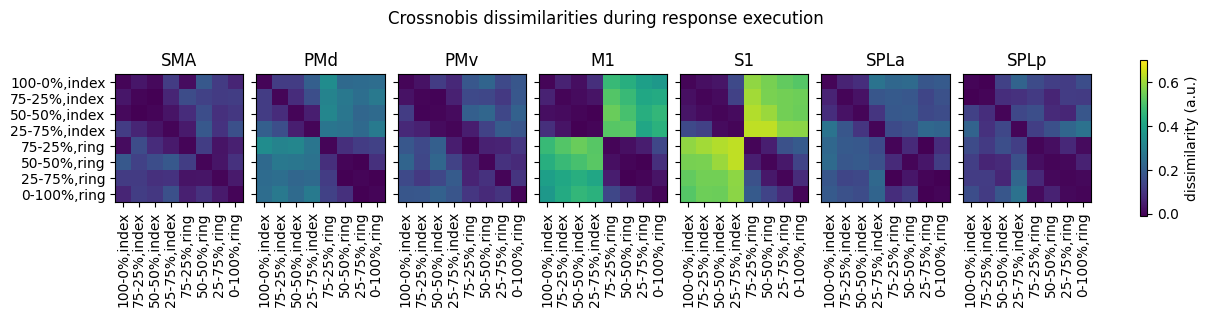

In [4]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .7

fig, axs = plt.subplots(1, len(rois), figsize=(12, 3),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(ROOT, 'data', 'encoding', f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

# log-Bayes factor for sensory input, expectation and surprise (Fig. 5c, see asterisks below bars)

T  dof alternative     p-val  \
roi  component                                                       
M1   expectation   T-test -8.605071e-01   13     greater  0.797450   
     sensory input T-test  3.751394e+00   13     greater  0.001211   
     surprise      T-test  2.414963e+00   13     greater  0.015599   
PMd  expectation   T-test -4.487225e+00   13     greater  0.999694   
     sensory input T-test  2.811922e+00   13     greater  0.007345   
     surprise      T-test  4.816956e+00   13     greater  0.000168   
PMv  expectation   T-test -2.683086e+06   13     greater  1.000000   
     sensory input T-test  1.346271e+00   13     greater  0.100611   
     surprise      T-test  3.224276e+00   13     greater  0.003325   
S1   expectation   T-test  2.428864e+00   13     greater  0.015198   
     sensory input T-test  4.937431e+00   11     greater  0.000222   
     surprise      T-test  2.905998e+00   13     greater  0.006133   
SMA  expectation   T-test -3.832919e+05   13     greater  1.000000   
     sensory input T-test -4.374745e-01   13     greater  0.665526   
     surprise      T-test  3.481731e+00   13     greater  0.002027   
SPLa expectation   T-test -1.261594e+00   13     greater  0.885369   
     sensory input T-test  2.110753e+00   13     greater  0.027367   
     surprise      T-test  3.695127e+00   13     greater  0.001347   
SPLp expectation   T-test -1.442660e+04   13     greater  1.000000   
     sensory input T-test -7.513958e-01   13     greater  0.767100   
     surprise      T-test  2.692395e+00   13     greater  0.009230   

                                   CI95%        cohen-d       BF10  \
roi  component                                                       
M1   expectation   T-test   [-0.83, inf]       0.229980      0.742   
     sensory input T-test   [57.91, inf]       1.002602     36.962   
     surprise      T-test    [2.24, inf]       0.645426      4.546   
PMd  expectation   T-test   [-1.01, inf]       1.199261      0.008   
     sensory input T-test    [5.13, inf]       0.751518      8.301   
     surprise      T-test   [15.89, inf]       1.287386    199.965   
PMv  expectation   T-test    [-1.0, inf]  717085.027558  1.442e-22   
     sensory input T-test   [-1.17, inf]       0.359806      1.143   
     surprise      T-test    [5.24, inf]       0.861724     15.887   
S1   expectation   T-test    [0.98, inf]       0.649141       4.64   
     sensory input T-test  [146.32, inf]       1.425314    159.715   
     surprise      T-test    [6.96, inf]       0.776661      9.611   
SMA  expectation   T-test    [-1.0, inf]  102439.082232  1.442e-22   
     sensory input T-test   [-1.05, inf]       0.116920      0.587   
     surprise      T-test    [6.13, inf]       0.930532     23.977   
SPLa expectation   T-test   [-1.32, inf]       0.337175      0.954   
     sensory input T-test    [0.74, inf]       0.564123      2.937   
     surprise      T-test   [12.46, inf]       0.987564      33.77   
SPLp expectation   T-test    [-1.0, inf]    3855.671377  1.444e-22   
     sensory input T-test   [-0.85, inf]       0.200819      0.689   
     surprise      T-test    [8.68, inf]       0.719573      6.904   

                                  power  
roi  component                           
M1   expectation   T-test  6.897545e-03  
     sensory input T-test  9.713906e-01  
     surprise      T-test  7.394321e-01  
PMd  expectation   T-test  1.554279e-09  
     sensory input T-test  8.452454e-01  
     surprise      T-test  9.981559e-01  
PMv  expectation   T-test  0.000000e+00  
     sensory input T-test  3.561751e-01  
     surprise      T-test  9.200027e-01  
S1   expectation   T-test  7.436764e-01  
     sensory input T-test  9.984773e-01  
     surprise      T-test  8.654191e-01  
SMA  expectation   T-test  0.000000e+00  
     sensory input T-test  1.968156e-02  
     surprise      T-test  9.502913e-01  
SPLa expectation   T-test  2.225986e-03  
     sensory input T-test  6.384256e-01  
     surprise     

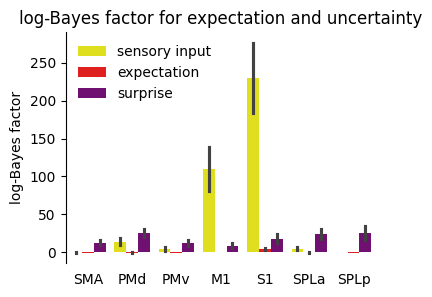

In [5]:
df = pd.read_csv(os.path.join(ROOT, 'data', 'encoding', 'component_model.BOLD.tsv'), sep='\t')
df = df[(df['epoch']=='exec') & (df['Hem']==H)]
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='component', palette = palette, errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('log-Bayes factor')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation and uncertainty')
results = df.groupby(['roi', 'component']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

# Standardised weight of sensory input, expectation and surprise (Fig. 5c)

Contrast              A              B  Paired  Parametric         T  \
roi                                                                             
M1   0  component    expectation  sensory input    True        True -4.252329   
     1  component    expectation       surprise    True        True -3.511405   
     2  component  sensory input       surprise    True        True  3.422511   
PMd  0  component    expectation  sensory input    True        True -4.126820   
     1  component    expectation       surprise    True        True -7.075389   
     2  component  sensory input       surprise    True        True -1.564788   
PMv  0  component    expectation  sensory input    True        True -1.901563   
     1  component    expectation       surprise    True        True -6.383358   
     2  component  sensory input       surprise    True        True -1.818985   
S1   0  component    expectation  sensory input    True        True -3.720313   
     1  component    expectation       surprise    True        True -2.606232   
     2  component  sensory input       surprise    True        True  3.346903   
SMA  0  component    expectation  sensory input    True        True -2.183822   
     1  component    expectation       surprise    True        True -7.711703   
     2  component  sensory input       surprise    True        True -4.815636   
SPLa 0  component    expectation  sensory input    True        True -3.018857   
     1  component    expectation       surprise    True        True -7.305102   
     2  component  sensory input       surprise    True        True -3.034417   
SPLp 0  component    expectation  sensory input    True        True -2.605778   
     1  component    expectation       surprise    True        True -5.836398   
     2  component  sensory input       surprise    True        True -4.871809   

         dof alternative     p-unc       BF10    hedges  
roi                                                      
M1   0  13.0        less  0.000472     82.347 -1.518076  
     1  13.0        less  0.001915     25.145 -1.279439  
     2  13.0        less  0.997729      0.046  1.262930  
PMd  0  13.0        less  0.000596      67.43 -1.266021  
     1  13.0        less  0.000004   5162.618 -2.324705  
     2  13.0        less  0.070821      1.455 -0.401686  
PMv  0  13.0        less  0.039811      2.212 -0.697790  
     1  13.0        less  0.000012   2017.388 -2.342415  
     2  13.0        less  0.046007      1.987 -0.661682  
S1   0  13.0        less  0.001284     35.163 -1.315554  
     1  13.0        less  0.010874      6.054 -1.037440  
     2  13.0        less  0.997374      0.052  1.217370  
SMA  0  13.0        less  0.023949      3.254 -0.801364  
     1  13.0        less  0.000002  1.172e+04 -2.829856  
     2  13.0        less  0.000169    199.556 -1.850000  
SPLa 0  13.0        less  0.004937     11.473 -0.733174  
     1  13.0        less  0.000003   6973.919 -2.239721  
     2  13.0        less  0.004792     11.758 -0.916984  
SPLp 0  13.0        less  0.010883      6.049 -0.961212  
     1  13.0        less  0.000029     925.94 -2.152169  
     2  13.0        less  0.000153    217.688 -1.830473

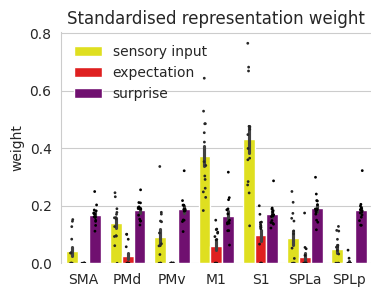

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))
df['norm_weight'] = np.sqrt(df['weight']/ df['noise'])
sb.barplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', palette = palette, errorbar='se', estimator='mean')
sb.stripplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='less'))
display(res)
plt.show()

# Sensory input relative to sensory input+surprise in M1-S1 vs. premotor-parietal areas (Fig. 5d)


M1-S1 vs. premotor parietal (one-sided t-test): tval=12.162, pval=0.000


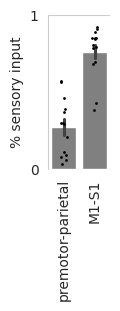

In [7]:
df_cluster = df.groupby(['cluster', 'participant_id', 'component']).mean(numeric_only=True).reset_index()
df_exp = df_cluster[df_cluster['component']=='sensory input']
df_sum = df_cluster.groupby(['cluster', 'participant_id']).sum(numeric_only=True).reset_index()
df_ratio = df_exp.copy()
df_ratio['ratio'] = df_exp['weight'].to_numpy() / df_sum['weight'].to_numpy()
df_ratio['cluster'] = pd.Categorical(df_ratio['cluster'], categories=['premotor-parietal','M1-S1'],ordered=True)

fig, ax = plt.subplots(figsize=(.8, 2))

sb.barplot(data=df_ratio, x='cluster', y='ratio', errorbar='se', color='grey')
sb.stripplot(data=df_ratio, x='cluster', y='ratio', size=2, color='black', jitter=.1, dodge=True, legend=False, order=['premotor-parietal','M1-S1'])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.tick_params(axis='x', bottom=False,)
ax.set_xlabel('')
ax.set_yticks((0, 1))
ax.set_xticklabels(['premotor-parietal', 'M1-S1'], rotation=90)
ax.set_ylabel('% sensory input')

m1_s1 = df_ratio[df_ratio['cluster']=='M1-S1'].ratio.to_numpy()
pmd_spl = df_ratio[df_ratio['cluster']=='premotor-parietal'].ratio.to_numpy()
tval, pval = ttest_1samp(m1_s1 - pmd_spl, popmean=0, alternative='greater')
print(f'M1-S1 vs. premotor parietal (one-sided t-test): tval={tval:.3f}, pval={pval:.3f}')
plt.show()